# LOL Game Results Prediction — XGBoost/LightGBM baseline model

In [1]:
# !pip install xgboost
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('loading complete')

loading complete


## 1. load data

In [3]:
import os

files = [
    'data/match_data_diamond1.csv',
    'data/match_data_diamond2.csv',
    'data/match_data_diamond3.csv',
    'data/match_data_diamond4.csv',
    'data/match_data_emerald1.csv',
]

dfs = []
for f in files:
    tmp = pd.read_csv(f)
    tmp['source'] = os.path.basename(f)
    dfs.append(tmp)
    print(f'{f}: {len(tmp)} games')

df = pd.concat(dfs, ignore_index=True)
print(f'\ntotal: {len(df)} plays，{len(df.columns)} columns')

data/match_data_diamond1.csv: 3966 games
data/match_data_diamond2.csv: 4743 games
data/match_data_diamond3.csv: 1753 games
data/match_data_diamond4.csv: 4147 games
data/match_data_emerald1.csv: 4855 games

total: 19464 plays，159 columns


## 2. data processing

In [4]:
# 1. Identify string columns
drop_cols = ['win', 'matchId', 'source']
str_cols = df.select_dtypes(include='object').columns.tolist()

# Remove 'matchId' and 'source' from str_cols if they are in it, as we want to drop them entirely
str_cols = [col for col in str_cols if col not in drop_cols]

# 2. Convert string columns to 'category' data type for XGBoost native support
for col in str_cols:
    df[col] = df[col].astype('category')

In [5]:
# 3. Define Features (X) and Target (y)
y = df['win']
X = df.drop(columns=drop_cols)

# fill missing values for numerical columns (NaNs)
num_cols = X.select_dtypes(exclude=['category']).columns
X[num_cols] = X[num_cols].fillna(0)

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'training: {len(X_train)} plays')
print(f'testing: {len(X_test)} plays')

training: 15571 plays
testing: 3893 plays


In [6]:
# 5. Train XGBoost with native categorical support
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',          # Required for categorical support
    enable_categorical=True,     # Enable native categorical feature handling
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.67387
[50]	validation_0-logloss:0.57594
[100]	validation_0-logloss:0.58051
[150]	validation_0-logloss:0.59036
[200]	validation_0-logloss:0.60748
[250]	validation_0-logloss:0.62007
[299]	validation_0-logloss:0.63217


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

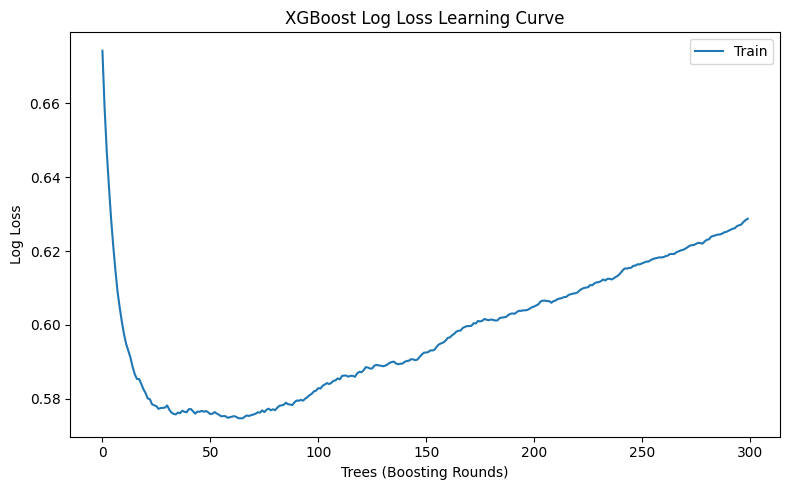

In [18]:
# visualization
import matplotlib.pyplot as plt

# access XGBoost evals
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

# Log Loss curve
plt.figure(figsize=(8, 5))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
# Check if validation_1 exists before plotting it
if 'validation_1' in results:
    plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
    plt.legend()
else:
    plt.legend(['Train'])  # Only show Train in legend if no Test data
plt.ylabel('Log Loss')
plt.xlabel('Trees (Boosting Rounds)')
plt.title('XGBoost Log Loss Learning Curve')
plt.tight_layout()
plt.show()

## 3. Train the XGBoost baseline model

In [7]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    enable_categorical=True  # Add this parameter to handle categorical features
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)
print('training complete')

[0]	validation_0-logloss:0.67427
[50]	validation_0-logloss:0.57585
[100]	validation_0-logloss:0.58288
[150]	validation_0-logloss:0.59251
[200]	validation_0-logloss:0.60497
[250]	validation_0-logloss:0.61667
[299]	validation_0-logloss:0.62876
training complete


## 4. Simple Evaluation

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 40)
print(f'Accuracy: {acc:.4f}')
print(f'AUC-ROC:           {auc:.4f}')
print('=' * 40)
print()
print(classification_report(y_test, y_pred, target_names=['lose', 'win']))

Accuracy: 0.6948
AUC-ROC:           0.7703

              precision    recall  f1-score   support

        lose       0.69      0.70      0.70      1925
         win       0.70      0.68      0.69      1968

    accuracy                           0.69      3893
   macro avg       0.69      0.69      0.69      3893
weighted avg       0.70      0.69      0.69      3893



## 5. Cross validation
Since a single application of `train_test_split` introduces randomness, reporting baseline performance using the mean of cross-validation results makes for a more robust argument in both academic and engineering contexts.

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate CV AUC scores 
# We use the base model to see how it performs across different subsets
cv_scores = cross_val_score(
    model, X, y, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

print(f"5-Fold CV AUC Scores: {cv_scores}")
print(f"Mean CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:09:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:09:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:09:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [09:09:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

5-Fold CV AUC Scores: [0.76545847 0.78564618 0.77126861 0.78310817 0.76471837]
Mean CV AUC: 0.7740 (+/- 0.0176)


## 6. Confusion Matrix

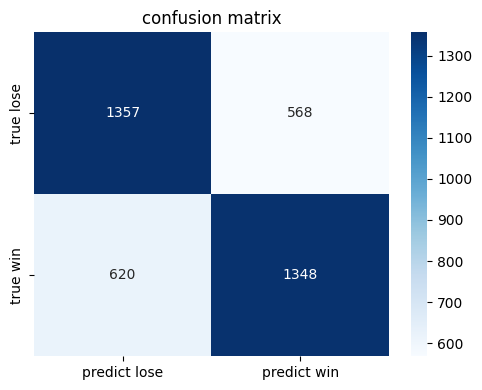

In [10]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['predict lose', 'predict win'],
            yticklabels=['true lose', 'true win'])
plt.title('confusion matrix')
plt.tight_layout()
plt.show()

## 7. feature importance

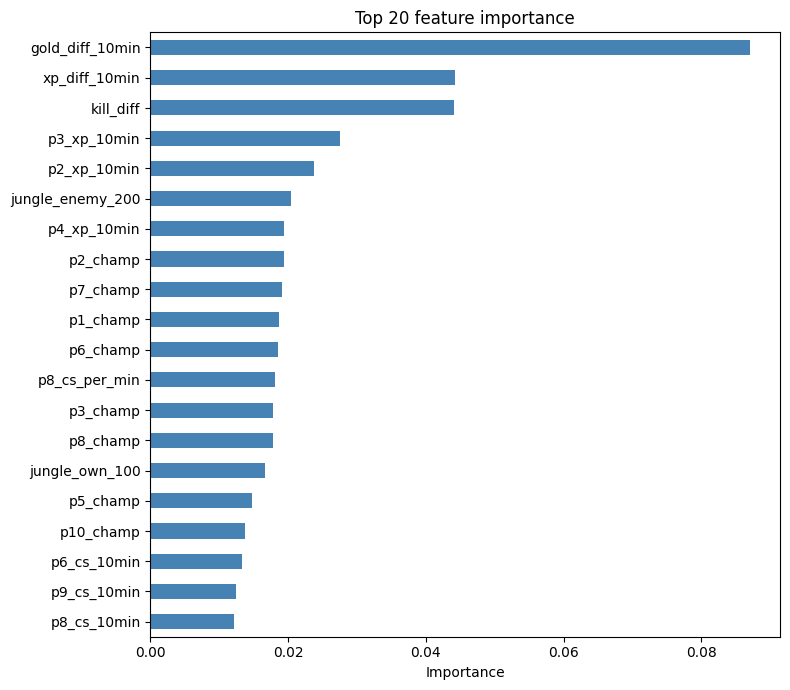


Top 20 features are:
gold_diff_10min     0.087072
xp_diff_10min       0.044291
kill_diff           0.044038
p3_xp_10min         0.027488
p2_xp_10min         0.023752
jungle_enemy_200    0.020394
p4_xp_10min         0.019472
p2_champ            0.019456
p7_champ            0.019139
p1_champ            0.018722
p6_champ            0.018611
p8_cs_per_min       0.018089
p3_champ            0.017768
p8_champ            0.017768
jungle_own_100      0.016653
p5_champ            0.014778
p10_champ           0.013753
p6_cs_10min         0.013347
p9_cs_10min         0.012444
p8_cs_10min         0.012190


In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
top20 = importance.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 20 features are:')
print(top20.to_string())

## 8. ROC curve

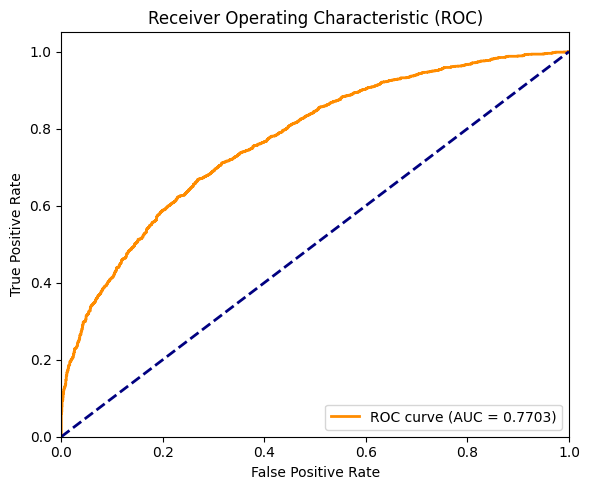

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities for the positive class (Win)
y_prob = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 10. LightGBM

In [15]:
import lightgbm as lgb
import time

print("training LightGBM baseline model...")
start_time = time.time()

# LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['train', 'valid'],
    eval_metric='logloss'
)

print(f"LightGBM training time: {time.time() - start_time:.2f} seconds")

# evaluate LightGBM
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
print(f'LightGBM Accuracy: {accuracy_score(y_test, lgb_pred):.4f}')
print(f'LightGBM AUC: {roc_auc_score(y_test, lgb_prob):.4f}')

training LightGBM baseline model...
[LightGBM] [Info] Number of positive: 7870, number of negative: 7701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21810
[LightGBM] [Info] Number of data points in the train set: 15571, number of used features: 156
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.505427 -> initscore=0.021708
[LightGBM] [Info] Start training from score 0.021708
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

## 9. SHAP

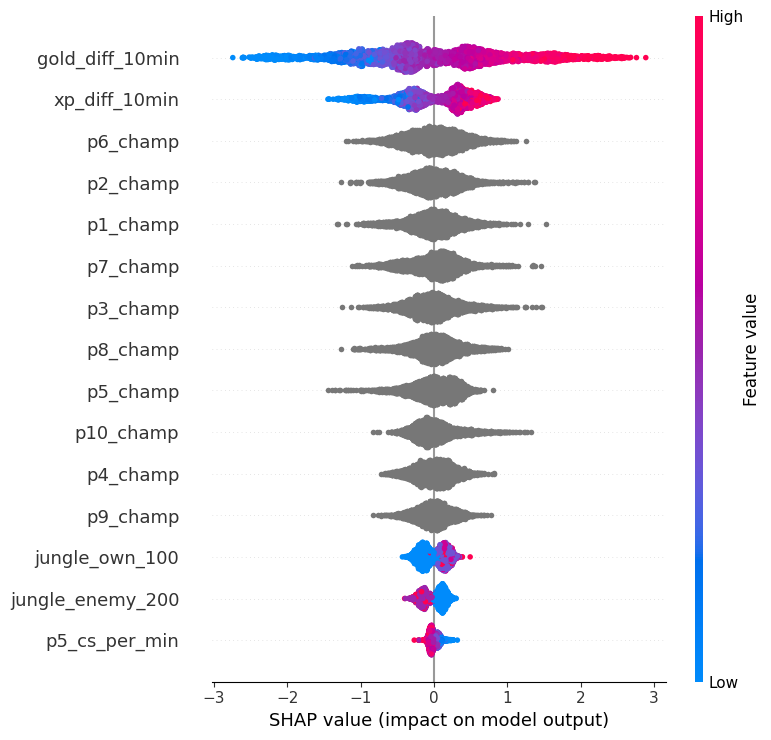

In [21]:
#!pip install shap
import shap

# calculate SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# plot SHAP (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15)